PyTorch implementation of the **All Convolutional Net** discussed in _'Striving for Simplicity: The All Convolutional Net'_ (Springenberg et al., 2014)

In [1]:
import time     # for recording training duration
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl

First, we implement a standard CNN with max-pooling layers to compare with its AllConv counterpart containing only convolutional layers. To understand the impact of data augmentation and batch normalisation on the results, we will create models with/without them for both cases.

We will evaluate the accuracy of these models on the CIFAR-10 dataset.

For reproducibility of results, we'll use a specific random seed, and also force determinism in cuDNN.

In [4]:
seed = 26
torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    # forces cuDNN to use deterministic algorithms only
    torch.backends.cudnn.deterministic = True
    # disables cuDNN autotuner that selects optimal algorithm based on hardware
    torch.backends.cudnn.benchmark = False

/home2/sian/summer-project/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
# hyperparameters
learningrate = 0.001
batchsize = 128
epochs = 10

momentum = 0.9

In [6]:
datapath = '../data'

# loading CIFAR-10 dataset
train_cifar10 = datasets.CIFAR10(
    root=datapath,
    train=True,
    download=True,
    transform=transforms.ToTensor()     # here, transforms.toTensor() also normalises pixel values to [0, 1]
)
test_cifar10 = datasets.CIFAR10(
    root=datapath,
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

# setting up dataloaders
trainloader_cifar10 = DataLoader(
    train_cifar10, 
    batch_size=batchsize, 
    shuffle=True                        # allows samples to be distributed among classes to reduce bias
)
testloader_cifar10 = DataLoader(
    test_cifar10, 
    batch_size=batchsize, 
    shuffle=False
)

In [7]:
# retrieving class names
with open(datapath + "/cifar-10-batches-py/batches.meta", "rb") as f:
    metadata = pkl.load(f, encoding="ASCII")
    classes = metadata["label_names"]

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


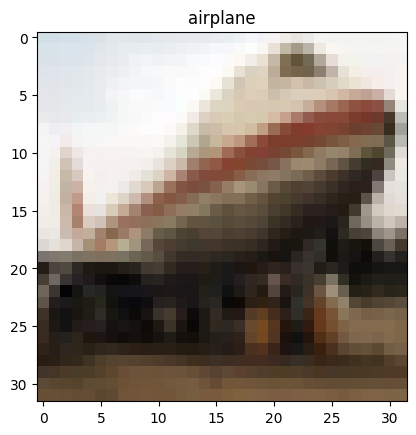

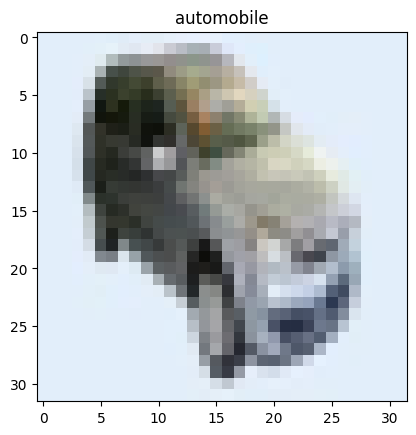

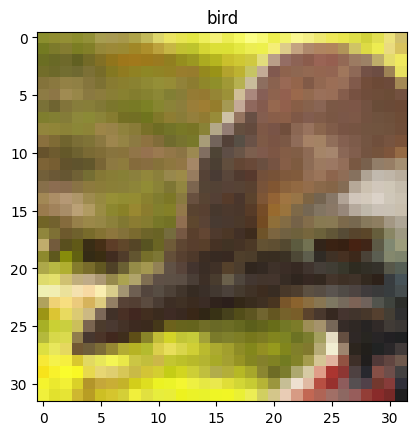

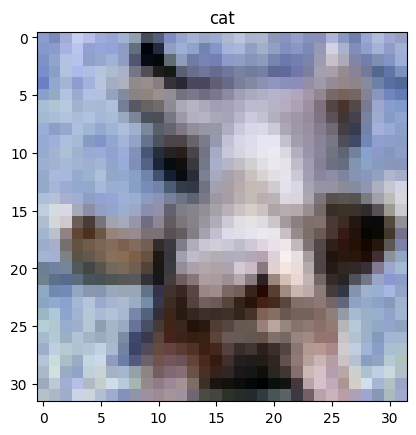

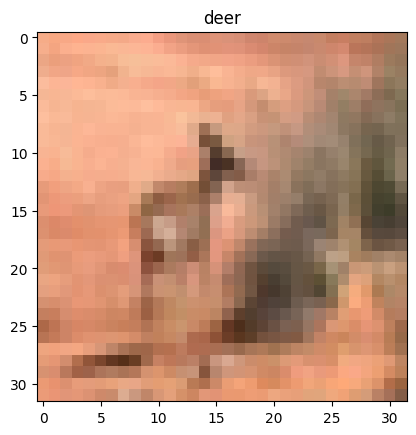

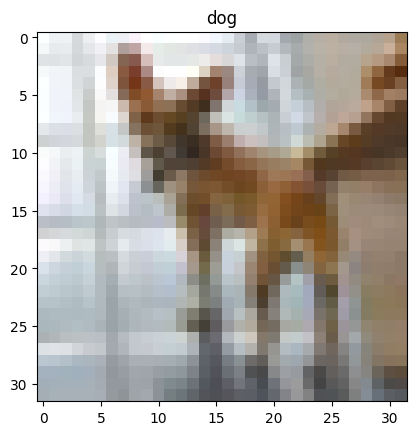

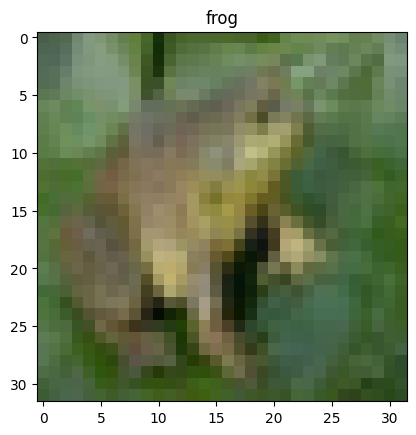

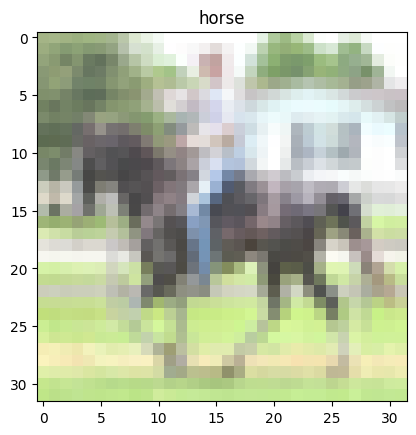

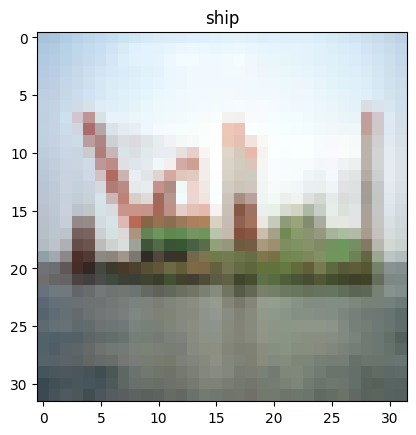

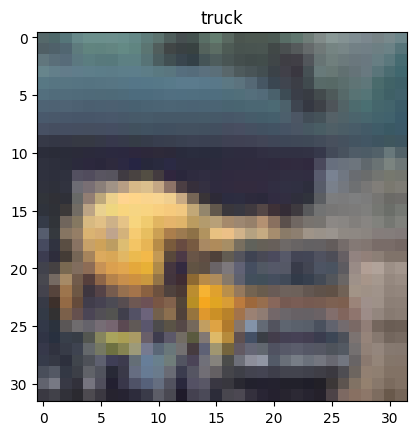

In [8]:
# retrieve a batch from training data (cifar10 is divided into five batches of 10k)
images, labels = next(iter(trainloader_cifar10))
# display an example image from each class
for i in range(10):
    index = np.argmax(labels.numpy() == i)
    plt.imshow(images[index].permute(1, 2, 0))     # permute to (H, W, C) for plotting
    plt.title(classes[labels[index]])
    plt.show()


We now implement the AllConv class, along with a BaseCNN class for comparison, referring to the architectures described in the allconv paper. We will initially evaluate accuracy without applying regularisation methods such as dropout and batch normalisation.

In [9]:
class AllConv(nn.Module):
    def __init__(self, inputsize, classcount, flag_dropout=True):
        super().__init__()                          # AllConv class inherits from nn.Module, so this initialises an instance of parent class

        # these are PyTorch classes in the nn module, so create an instance before calling
        self.conv1 = nn.Conv2d(in_channels = inputsize, out_channels = 96, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = 96, out_channels = 96, kernel_size = 3, padding = 1)
        # now, replace first maxpool with strided conv
        self.conv3 = nn.Conv2d(in_channels = 96, out_channels = 96, kernel_size = 3, padding = 1, stride = 2)

        self.conv4 = nn.Conv2d(in_channels = 96, out_channels = 192, kernel_size = 3, padding = 1)
        self.conv5 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        # second maxpool also replaced with strided conv
        self.conv6 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1, stride = 2)

        self.conv7 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.conv8 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 1)
        
        # final conv with 10 output channels to replace fully connected layer
        self.fullconv = nn.Conv2d(in_channels = 192, out_channels = classcount, kernel_size = 1)

        # the paper applies dropout of 0.2 to inputs and 0.5 after each pooling layer
        # uses a flag to test how using dropout affects accuracy
        self.dropout = flag_dropout

    def forward(self, o):
        # also, since we use functional dropout, we need to specify if model is in train/eval mode
        o = (F.dropout(o, p=0.2, training=self.training) if self.dropout else o)
        o = F.relu(self.conv1(o))
        o = F.relu(self.conv2(o))
        o = F.relu(self.conv3(o))

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.conv4(o))
        o = F.relu(self.conv5(o))
        o = F.relu(self.conv6(o))

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.conv7(o))
        o = F.relu(self.conv8(o))

        # the paper says apply a ReLU here, but it might be counterintuitive
        # try it and see if accuracy changes
        o = F.relu(self.fullconv(o))

        logits = F.adaptive_avg_pool2d(o, 1)
        # now, image is 1x1, so drop redundant dimensions
        # ~note~: underscored method indicates in-place modification
        # .squeeze_() later replaced with flatten() here
        logits = torch.flatten(logits, start_dim=1)
        return logits

In [10]:
class BaseCNN(nn.Module):
    def __init__(self, inputsize, classcount, flag_dropout=True):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels = inputsize, out_channels = 96, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = 96, out_channels = 96, kernel_size = 3, padding = 1)
        self.pool1 = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.conv3 = nn.Conv2d(in_channels = 96, out_channels = 192, kernel_size = 3, padding = 1)
        self.conv4 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.pool2 = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

        self.conv5 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 3, padding = 1)
        self.conv6 = nn.Conv2d(in_channels = 192, out_channels = 192, kernel_size = 1)

        # here for BaseCNN we still use a conv layer instead of a fully connected layer
        self.fullconv = nn.Conv2d(in_channels = 192, out_channels = classcount, kernel_size = 1)

        # flag to test how dropout affects accuracy
        self.dropout = flag_dropout

    def forward(self, o):
        o = (F.dropout(o, p=0.2, training=self.training) if self.dropout else o)
        o = F.relu(self.conv1(o))
        o = F.relu(self.conv2(o))
        o = self.pool1(o)

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.conv3(o))
        o = F.relu(self.conv4(o))
        o = self.pool2(o)

        o = (F.dropout(o, p=0.5, training=self.training) if self.dropout else o)
        o = F.relu(self.conv5(o))
        o = F.relu(self.conv6(o))

        # the paper says apply a ReLU here, but it might be counterintuitive
        o = F.relu(self.fullconv(o))

        logits = F.adaptive_avg_pool2d(o, 1)
        logits = torch.flatten(logits, start_dim=1)
        return logits

We've now defined the classes, so we create the training loop and check accuracy on the CIFAR-10 dataset without dropout.

In [11]:
# ~note~: PyTorch 4d tensors have format (BATCHSIZE, CHANNELS, HEIGHT, WIDTH)

def train(model, trainloader, testloader, epochs, learningrate):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model.to(device)
    # loss function
    criterion = nn.CrossEntropyLoss()
    # the paper uses SGD with momentum
    optimiser = torch.optim.SGD(model.parameters(), lr=learningrate, momentum=0.9)
    # scheduler for adaptive learning rate
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)

    start = time.time()
    for epoch in range(epochs):
        model.train()
        runningloss = 0.0
        correct_train_samples = 0
        total_train_samples = 0

        for images, labels in trainloader:
            # move data to gpu
            images = images.to(device)
            labels = labels.to(device)
            # clear gradients
            optimiser.zero_grad()
            # forward pass
            logits = model(images)
            # loss calc
            loss = criterion(logits, labels)
            # backward pass
            loss.backward()
            # weight update
            optimiser.step()

            # loss returned is a tensor, so .item() returns float value
            # multiply by batch size to get net loss for batch
            runningloss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, axis=1)
            total_train_samples += labels.size(0)
            correct_train_samples += (predicted == labels).sum().item()

        # lr update
        scheduler.step()

        trainloss = runningloss / total_train_samples
        trainacc = 100 * (correct_train_samples / total_train_samples)

        # we will also evaluate on test set after each epoch for ease of adjusting hyperparameters
        model.eval()
        correct_test_samples = 0
        total_test_samples = 0

        # freezes weights so model doesn't learn from test set
        with torch.no_grad():
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                logits = model(images)
                _, predicted = torch.max(logits, axis=1)
                total_test_samples += labels.size(0)
                correct_test_samples += (predicted == labels).sum().item()

        testacc = 100 * (correct_test_samples / total_test_samples)

        print(f"epoch: {epoch+1}/{epochs}\ttrain loss: {trainloss:.4f}\ttrain acc: {trainacc:.2f}%\ttest acc: {testacc:.2f}%")
    
    print("Finished training. Time elapsed: {:.2f} minutes".format((time.time() - start)/60))
    return model

In [ ]:
basecnn_noreg = BaseCNN(inputsize=3, classcount=10, flag_dropout=False)
trained_basecnn_noreg = train(basecnn_noreg, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

In [ ]:
allconv_noreg = AllConv(inputsize=3, classcount=10, flag_dropout=False)
trained_allconv_noreg = train(allconv_noreg, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

In [ ]:
basecnn_dropout = BaseCNN(inputsize=3, classcount=10)
trained_basecnn_dropout = train(basecnn_dropout, trainloader_cifar10, testloader_cifar10, epochs, learningrate)

In [ ]:
allconv_dropout = AllConv(inputsize=3, classcount=10)
trained_allconv_dropout = train(allconv_dropout, trainloader_cifar10, testloader_cifar10, epochs, learningrate)